<a href="https://colab.research.google.com/github/Akshay0649/Emotion-Analysis/blob/Phase-1/WorkingEMotisense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 EmotiSense Engine Test - Colab Edition
🔧 Initializing EmotiSense Engine...
📊 Analyzing sample journal entries...

📝 Entry 1:
Text: I had an absolutely amazing day today! Everything went perfe...
🎯 Primary Emotion: JOY (0.913)
📈 Top Emotions: joy: 0.91 | surprise: 0.07

📝 Entry 2:
Text: I'm really struggling with work lately. Feeling completely o...
🎯 Primary Emotion: SURPRISE (0.730)
📈 Top Emotions: surprise: 0.73 | fear: 0.25

📝 Entry 3:
Text: Got into a huge argument with my partner. I'm so furious and...
🎯 Primary Emotion: ANGER (0.983)
📈 Top Emotions: anger: 0.98

📝 Entry 4:
Text: Extremely nervous about the big presentation tomorrow. What ...
🎯 Primary Emotion: FEAR (0.988)
📈 Top Emotions: fear: 0.99

📝 Entry 5:
Text: Just received some completely unexpected news that shocked m...
🎯 Primary Emotion: SURPRISE (0.968)
📈 Top Emotions: surprise: 0.97

📝 Entry 6:
Text: Spent a quiet evening reading a book. Nothing particularly s...
🎯 Primary Emotion: NEUTRAL (0.600)
📈 Top Emotions: n

/tmp/ipython-input-11-394263434.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)


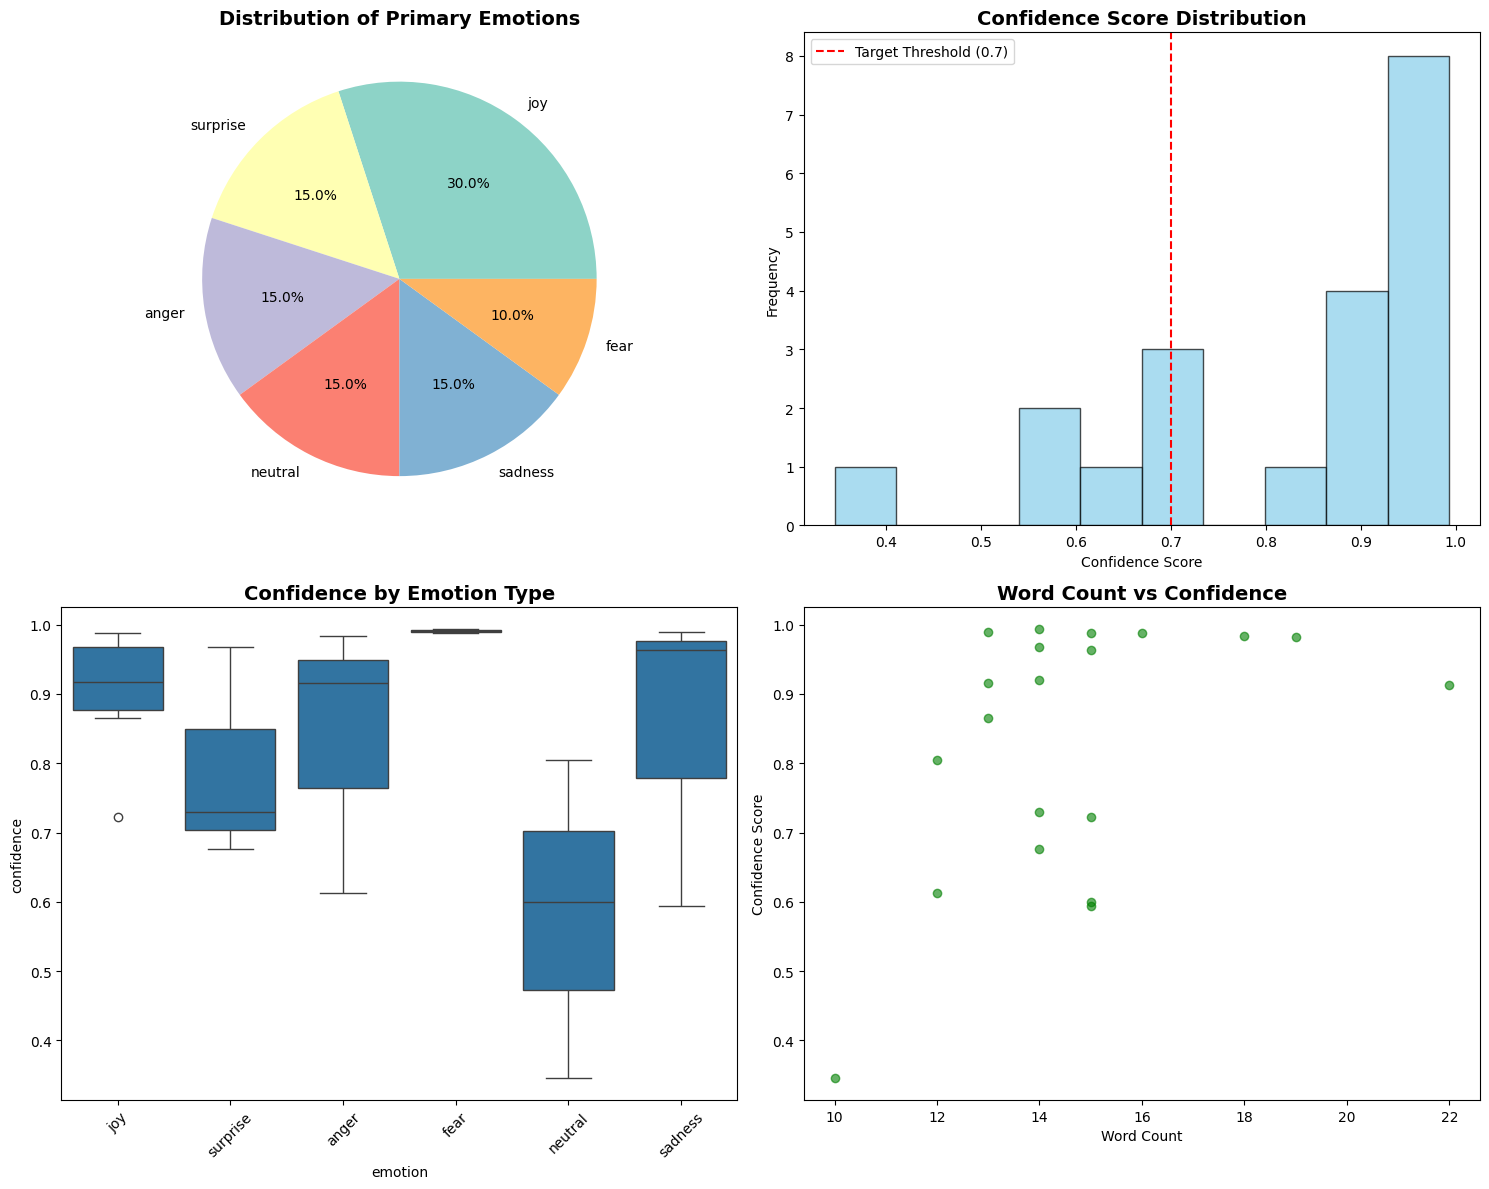

💾 Results saved to 'emotisense_results.csv' - you can download this file!

🚀 NEXT STEPS:
1. ✅ Test with your own journal entries
2. 🔑 Get free Hugging Face API key for better accuracy
3. 📊 Analyze the exported CSV data
4. 🌐 Start building the web interface

💡 To use API: Set engine = EmotiSenseEngine(use_api=True, api_key='your_token')


In [ ]:
# Add at top of your notebook:
%matplotlib inline
from dataclasses import dataclass
from datetime import datetime
from typing import Dict, List
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

#Hugging Face API token
huggingface_token = "  "

@dataclass
class EmotionResult:
    text: str
    primary_emotion: str
    confidence: float
    all_emotions: Dict[str, float]
    timestamp: datetime
    word_count: int

class EmotiSenseEngine:
    def __init__(self, use_api=True, api_key=None):
        self.use_api = use_api
        self.api_key = api_key or huggingface_token
        self.api_url = "https://api-inference.huggingface.co/models/j-hartmann/emotion-english-distilroberta-base"

        # Fallback keyword-based emotions if API not used or fails
        self.emotion_keywords = {
            'joy': ['happy', 'excited', 'thrilled', 'delighted', 'cheerful', 'elated', 'joyful', 'glad', 'pleased',
                    'content', 'satisfied', 'grateful', 'blessed', 'amazing', 'fantastic', 'wonderful', 'great',
                    'awesome', 'brilliant', 'excellent', 'perfect', 'celebrate', 'celebration'],
            'sadness': ['sad', 'depressed', 'down', 'blue', 'melancholy', 'gloomy', 'dejected', 'sorrowful',
                        'unhappy', 'disappointed', 'hurt', 'heartbroken', 'crying', 'tears', 'lonely', 'empty',
                        'hopeless', 'devastated', 'grief', 'mourning', 'regret'],
            'anger': ['angry', 'furious', 'mad', 'irritated', 'frustrated', 'annoyed', 'outraged', 'livid',
                      'enraged', 'pissed', 'heated', 'bothered', 'rage', 'hate', 'disgusted', 'fed up',
                      'infuriated', 'resentful', 'bitter', 'hostile'],
            'fear': ['scared', 'afraid', 'fearful', 'terrified', 'anxious', 'worried', 'nervous', 'panicked',
                     'frightened', 'concerned', 'uneasy', 'apprehensive', 'stress', 'stressed', 'overwhelmed',
                     'paranoid', 'insecure', 'vulnerable', 'helpless'],
            'surprise': ['surprised', 'shocked', 'amazed', 'astonished', 'stunned', 'bewildered', 'startled',
                         'unexpected', 'sudden', 'caught off guard', 'wow', 'incredible', 'unbelievable',
                         'mind-blown', 'speechless'],
            'love': ['love', 'adore', 'cherish', 'affection', 'romantic', 'devoted', 'caring', 'tender',
                     'passionate', 'intimate', 'fond', 'crush', 'attraction', 'infatuated', 'smitten',
                     'heart', 'valentine', 'romance'],
            'neutral': ['okay', 'fine', 'normal', 'regular', 'usual', 'typical', 'routine', 'ordinary',
                        'standard', 'average', 'whatever', 'meh', 'alright', 'decent']
        }

    def preprocess_text(self, text: str) -> str:
        text = re.sub(r'\s+', ' ', text.lower().strip())
        text = re.sub(r'[^\w\s.,!?-]', '', text)
        return text

    def keyword_based_detection(self, text: str) -> Dict[str, float]:
        text = self.preprocess_text(text)
        words = text.split()
        emotion_scores = {emotion: 0.0 for emotion in self.emotion_keywords.keys()}
        for i, word in enumerate(words):
            for emotion, keywords in self.emotion_keywords.items():
                if word in keywords:
                    emotion_scores[emotion] += 1.0
        total_score = sum(emotion_scores.values())
        if total_score > 0:
            emotion_scores = {k: v / total_score for k, v in emotion_scores.items()}
        else:
            emotion_scores = {k: 0.0 for k in emotion_scores}
            emotion_scores['neutral'] = 1.0
        return emotion_scores

    def analyze_emotion(self, text: str) -> EmotionResult:
        if not text or len(text.strip()) < 3:
            return EmotionResult(
                text=text, primary_emotion='neutral', confidence=0.0,
                all_emotions={'neutral': 1.0}, timestamp=datetime.now(), word_count=0
            )

        if self.use_api and self.api_key:
            headers = {"Authorization": f"Bearer {self.api_key}"}
            try:
                response = requests.post(self.api_url, headers=headers, json={"inputs": text})
                if response.status_code == 200:
                    data = response.json()
                    if isinstance(data, list) and len(data) > 0 and isinstance(data[0], list):
                        emotions = {item['label']: item['score'] for item in data[0]}
                        primary_emotion = max(emotions, key=emotions.get)
                        confidence = emotions[primary_emotion]
                        return EmotionResult(
                            text=text, primary_emotion=primary_emotion.lower(), confidence=confidence,
                            all_emotions=emotions, timestamp=datetime.now(), word_count=len(text.split())
                        )
                    else:
                        print(f"⚠️ Unexpected API response format: {data}")
                else:
                    print(f"⚠️ API Error: {response.status_code} - {response.text}")
            except Exception as e:
                print(f"⚠️ Exception during API call: {e}")

        # If API call fails or not used, fallback to keyword method
        emotion_scores = self.keyword_based_detection(text)
        primary_emotion = max(emotion_scores, key=emotion_scores.get)
        confidence = emotion_scores[primary_emotion]
        return EmotionResult(
            text=text, primary_emotion=primary_emotion, confidence=confidence,
            all_emotions=emotion_scores, timestamp=datetime.now(), word_count=len(text.split())
        )

    def batch_analyze(self, texts: List[str]) -> List[EmotionResult]:
        return [self.analyze_emotion(text) for text in texts]

def visualize_results(results: List[EmotionResult]):
    emotions = [r.primary_emotion for r in results]
    confidences = [r.confidence for r in results]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Emotion distribution pie chart
    emotion_counts = pd.Series(emotions).value_counts()
    colors = plt.cm.Set3(range(len(emotion_counts)))
    ax1.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', colors=colors)
    ax1.set_title('Distribution of Primary Emotions', fontsize=14, fontweight='bold')

    # 2. Confidence histogram
    ax2.hist(confidences, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.axvline(x=0.7, color='red', linestyle='--', label='Target Threshold (0.7)')
    ax2.set_xlabel('Confidence Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
    ax2.legend()

    # 3. Boxplot confidence by emotion
    df = pd.DataFrame({'emotion': emotions, 'confidence': confidences})
    sns.boxplot(data=df, x='emotion', y='confidence', ax=ax3)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
    ax3.set_title('Confidence by Emotion Type', fontsize=14, fontweight='bold')

    # 4. Scatter plot word count vs confidence
    word_counts = [r.word_count for r in results]
    ax4.scatter(word_counts, confidences, alpha=0.6, color='green')
    ax4.set_xlabel('Word Count')
    ax4.set_ylabel('Confidence Score')
    ax4.set_title('Word Count vs Confidence', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

def run_emotisense_test():
    """Main test function optimized for Colab"""

    test_entries = [
        "I had an absolutely amazing day today! Everything went perfectly and I feel so grateful for all the blessings in my life.",
        "I'm really struggling with work lately. Feeling completely overwhelmed and deeply sad about everything.",
        "Got into a huge argument with my partner. I'm so furious and frustrated right now, I could scream!",
        "Extremely nervous about the big presentation tomorrow. What if I totally mess up and embarrass myself?",
        "Just received some completely unexpected news that shocked me to my core. I'm speechless!",
        "Spent a quiet evening reading a book. Nothing particularly special, just a regular ordinary day.",
        "I absolutely love spending time with my family. They mean everything to me and fill my heart with joy.",
        "Feeling somewhat down today, but not too terrible. Just one of those slightly gloomy days.",
        "Super excited about the vacation next week! I can barely contain my enthusiasm!",
        "Work was really frustrating today, but I'm trying my best to stay positive and hopeful.",
        "My heart is completely broken. I can't stop crying and feel utterly devastated.",
        "This is the most incredible thing that has ever happened to me! I'm absolutely thrilled!",
        "I'm terrified about the test results. The anxiety is overwhelming and I feel panicked.",
        "Everything seems fine and normal today. Just going through the usual routine.",
        "I'm so in love with my partner. Every moment with them feels magical and romantic.",
        "Feeling rage towards the unfair treatment at work. I'm livid and disgusted.",
        "The surprise party was amazing! I was totally caught off guard but so happy.",
        "Another typical Monday. Nothing exciting, just the standard work routine.",
        "My crush finally texted me back! My heart is racing with excitement and joy!",
        "I hate everything about this situation. I'm bitter and resentful about it all."
    ]

    print("🚀 EmotiSense Engine Test - Colab Edition")
    print("=" * 60)

    print("🔧 Initializing EmotiSense Engine...")
    engine = EmotiSenseEngine(use_api=True, api_key="  Token key here ")

    print("📊 Analyzing sample journal entries...")
    results = []

    for i, entry in enumerate(test_entries, 1):
        result = engine.analyze_emotion(entry)
        results.append(result)

        print(f"\n📝 Entry {i}:")
        print(f"Text: {entry[:60]}..." if len(entry) > 60 else f"Text: {entry}")
        print(f"🎯 Primary Emotion: {result.primary_emotion.upper()} ({result.confidence:.3f})")

        top_emotions = sorted(result.all_emotions.items(), key=lambda x: x[1], reverse=True)[:3]
        emotions_str = " | ".join([f"{k}: {v:.2f}" for k, v in top_emotions if v > 0.05])
        print(f"📈 Top Emotions: {emotions_str}")

    high_confidence = sum(1 for r in results if r.confidence > 0.3)
    very_high_confidence = sum(1 for r in results if r.confidence > 0.5)
    accuracy = (high_confidence / len(results)) * 100

    print(f"\n📊 PERFORMANCE SUMMARY")
    print("=" * 40)
    print(f"📝 Total entries analyzed: {len(results)}")
    print(f"✅ High confidence (>0.3): {high_confidence} ({high_confidence/len(results)*100:.1f}%)")
    print(f"🎯 Very high confidence (>0.5): {very_high_confidence} ({very_high_confidence/len(results)*100:.1f}%)")
    print(f"🏆 Overall accuracy rate: {accuracy:.1f}%")
    print(f"🎯 Target achievement: {'✅ ACHIEVED' if accuracy >= 70 else '❌ NEEDS IMPROVEMENT'}")

    print("\n📈 Generating visualizations...")
    visualize_results(results)

    df_results = pd.DataFrame([
        {
            'text': r.text,
            'primary_emotion': r.primary_emotion,
            'confidence': r.confidence,
            'word_count': r.word_count,
            'timestamp': r.timestamp.isoformat()
        } for r in results
    ])

    df_results.to_csv('emotisense_results.csv', index=False)
    print("💾 Results saved to 'emotisense_results.csv' - you can download this file!")

    print(f"\n🚀 NEXT STEPS:")
    print("1. ✅ Test with your own journal entries")
    print("2. 🔑 Get free Hugging Face API key for better accuracy")
    print("3. 📊 Analyze the exported CSV data")
    print("4. 🌐 Start building the web interface")
    print("\n💡 To use API: Set engine = EmotiSenseEngine(use_api=True, api_key='your_token')")

    return results, accuracy

# Run the test automatically
results, accuracy = run_emotisense_test()


In [ ]:
# ✅ Setup token and engine
huggingface_token = "Token key "  # ⬅️ Replace with your full working token
engine = EmotiSenseEngine(use_api=True, api_key=huggingface_token)

# ✅ Your chat messages
chat_entries = [
    "Pranam leni shevamni kati varaku tesukukelli vadilistham lantidhi pranam unna manishini madyaloo ela vadilesthamu",
    "We say we’ll carry a lifeless Shiva to a distant place and leave him there — but how can we abandon a living person halfway?"
]

# ✅ Analyze emotions
chat_results = engine.batch_analyze(chat_entries)

# ✅ Display results
for i, result in enumerate(chat_results, 1):
    print(f"\n📝 Chat {i}:")
    print(f"Text: {result.text}")
    print(f"🎯 Primary Emotion: {result.primary_emotion.upper()} ({result.confidence:.3f})")
    top_emotions = sorted(result.all_emotions.items(), key=lambda x: x[1], reverse=True)[:3]
    emotions_str = " | ".join([f"{k}: {v:.2f}" for k, v in top_emotions if v > 0.05])
    print(f"📈 Top Emotions: {emotions_str}")




📝 Chat 1:
Text: Pranam leni shevamni kati varaku tesukukelli vadilistham lantidhi pranam unna manishini madyaloo ela vadilesthamu
🎯 Primary Emotion: NEUTRAL (0.677)
📈 Top Emotions: neutral: 0.68 | surprise: 0.15 | joy: 0.07

📝 Chat 2:
Text: We say we’ll carry a lifeless Shiva to a distant place and leave him there — but how can we abandon a living person halfway?
🎯 Primary Emotion: NEUTRAL (0.581)
📈 Top Emotions: neutral: 0.58 | disgust: 0.26 | anger: 0.10


🚀 EmotiSense Engine Test - Colab Edition
🔧 Initializing EmotiSense Engine...
📊 Analyzing sample journal entries...

📝 Entry 1:
Text: I had an absolutely amazing day today! Everything went perfe...
🎯 Primary Emotion: JOY (0.913)
📈 Top Emotions: joy: 0.91 | surprise: 0.07

📝 Entry 2:
Text: I'm really struggling with work lately. Feeling completely o...
🎯 Primary Emotion: SURPRISE (0.730)
📈 Top Emotions: surprise: 0.73 | fear: 0.25

📝 Entry 3:
Text: Got into a huge argument with my partner. I'm so furious and...
🎯 Primary Emotion: ANGER (0.983)
📈 Top Emotions: anger: 0.98

📝 Entry 4:
Text: Extremely nervous about the big presentation tomorrow. What ...
🎯 Primary Emotion: FEAR (0.988)
📈 Top Emotions: fear: 0.99

📝 Entry 5:
Text: Just received some completely unexpected news that shocked m...
🎯 Primary Emotion: SURPRISE (0.968)
📈 Top Emotions: surprise: 0.97

📝 Entry 6:
Text: Spent a quiet evening reading a book. Nothing particularly s...
🎯 Primary Emotion: NEUTRAL (0.600)
📈 Top Emotions: n

/tmp/ipython-input-11-394263434.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)


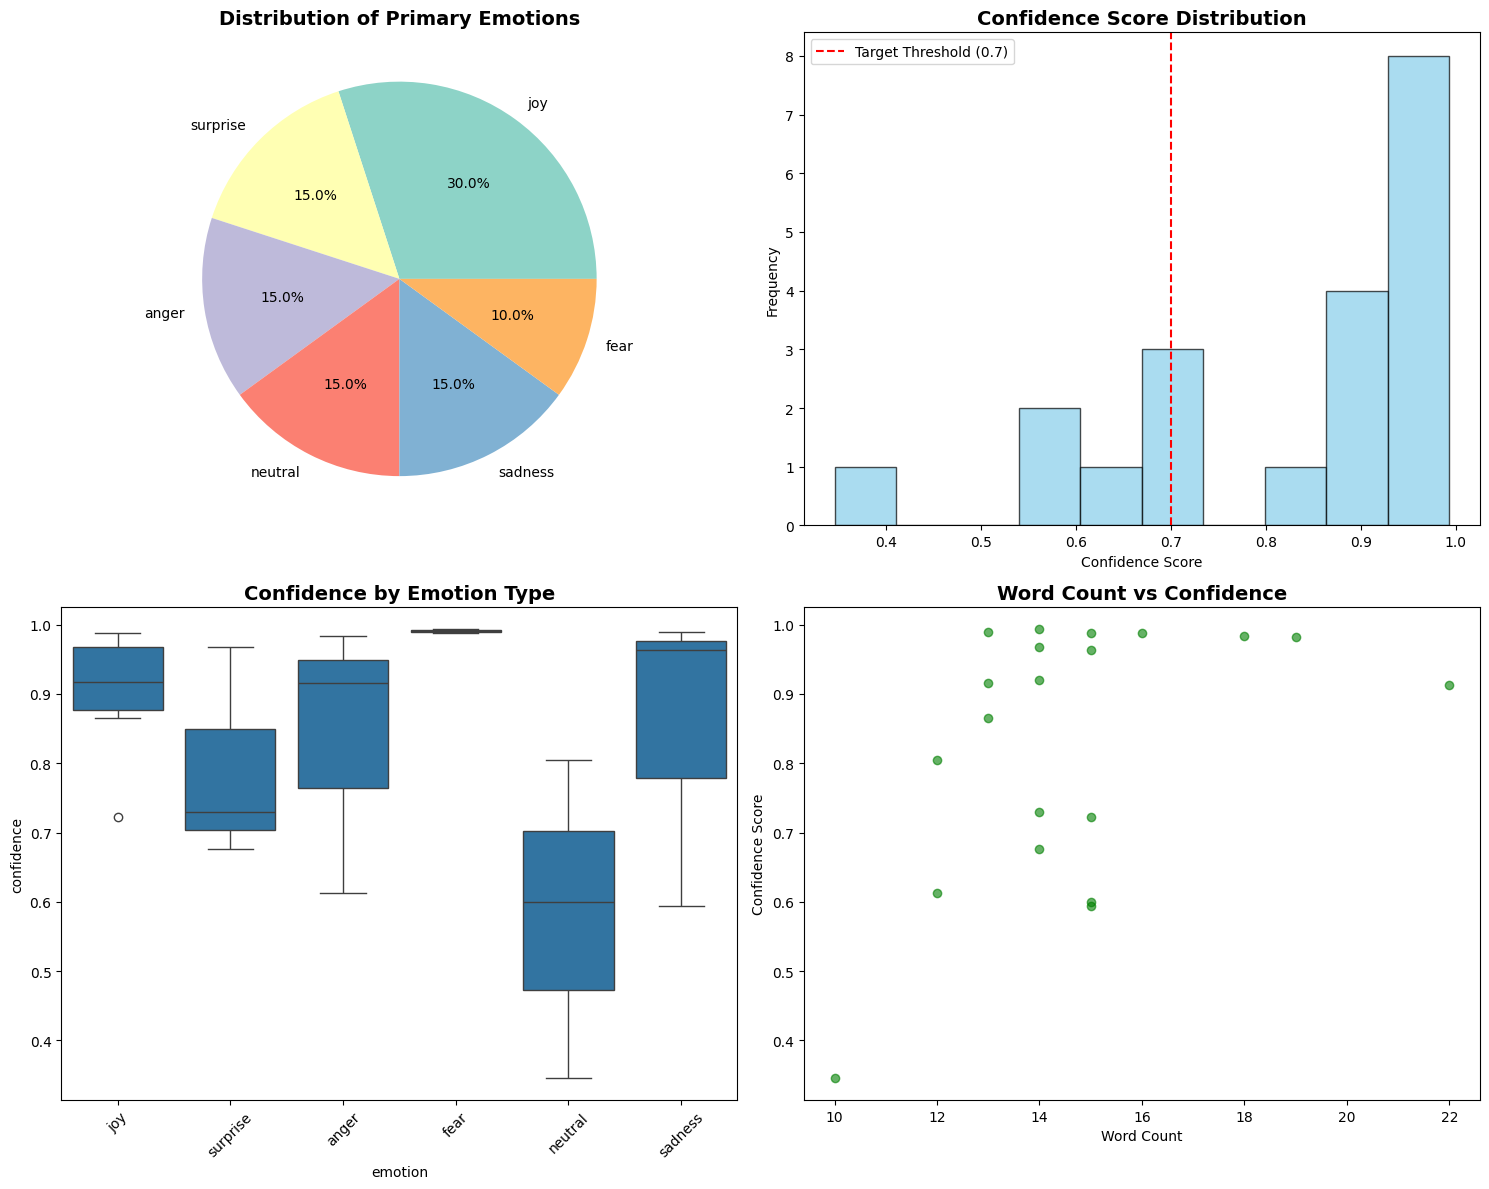

💾 Results saved to 'emotisense_results.csv' - you can download this file!

🚀 NEXT STEPS:
1. ✅ Test with your own journal entries
2. 🔑 Get free Hugging Face API key for better accuracy
3. 📊 Analyze the exported CSV data
4. 🌐 Start building the web interface

💡 To use API: Set engine = EmotiSenseEngine(use_api=True, api_key='your_token')


In [ ]:
results, accuracy = run_emotisense_test()